<a href="https://colab.research.google.com/github/PawaniMekhala/AI-Driven-Student-Dropout-Prediction/blob/main/06_explainability_SHAP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Mount Drive & Load Libraries
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

Mounted at /content/drive


In [ ]:
# Load Processed Data
PROJECT_ROOT = "/content/drive/MyDrive/student-dropout-prediction"

X_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_train.csv")
y_train = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_train.csv").values.ravel()

X_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/X_test.csv")
y_test = pd.read_csv(f"{PROJECT_ROOT}/data/processed/y_test.csv").values.ravel()

print(X_train.shape, X_test.shape)

(3539, 226) (885, 226)


In [ ]:
# Train Final XGBoost Model (Same as Before)
# Important: SHAP explanations must use the same trained model.
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=0.5,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.7, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=0.5,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=10, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Initialize SHAP Explainer
explainer = shap.TreeExplainer(xgb)

In [ ]:
# Compute SHAP Values (Test Set)
shap_values = explainer.shap_values(X_test)
# shap_values = explainer(X_test)

print("SHAP values shape:", shap_values.shape)
# Shape should be: (samples, features)

SHAP values shape: (885, 226)


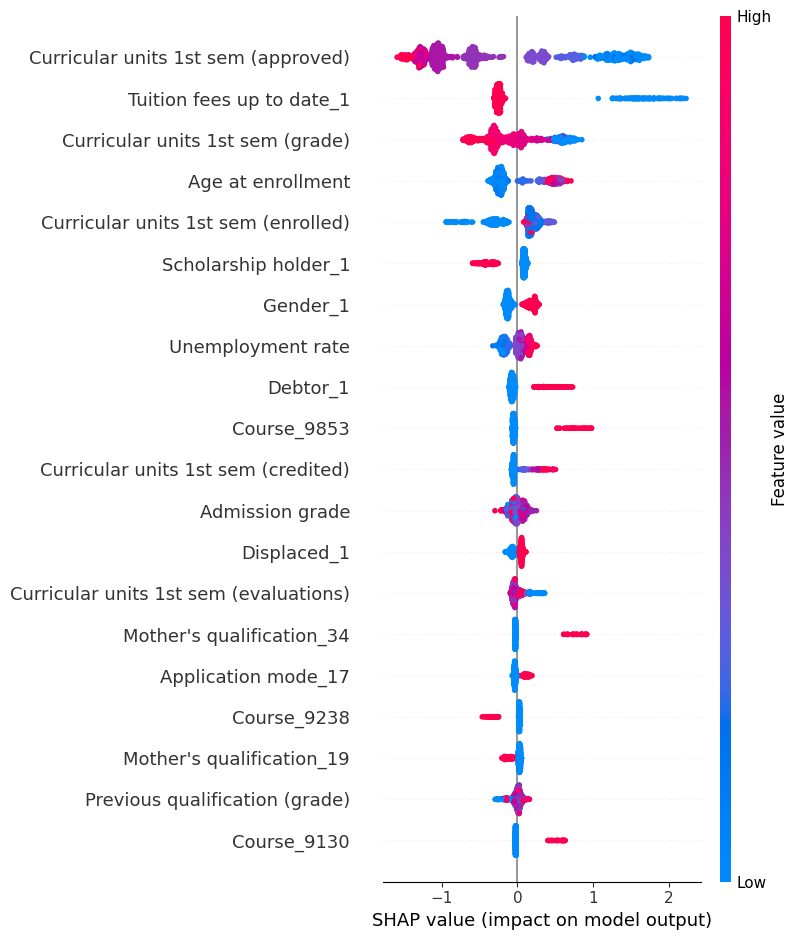

In [ ]:
# GLOBAL EXPLANATION — SHAP Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    show=True
)
# The SHAP summary plot illustrates the global contribution of features to dropout prediction, highlighting early academic performance and financial variables as dominant predictors.

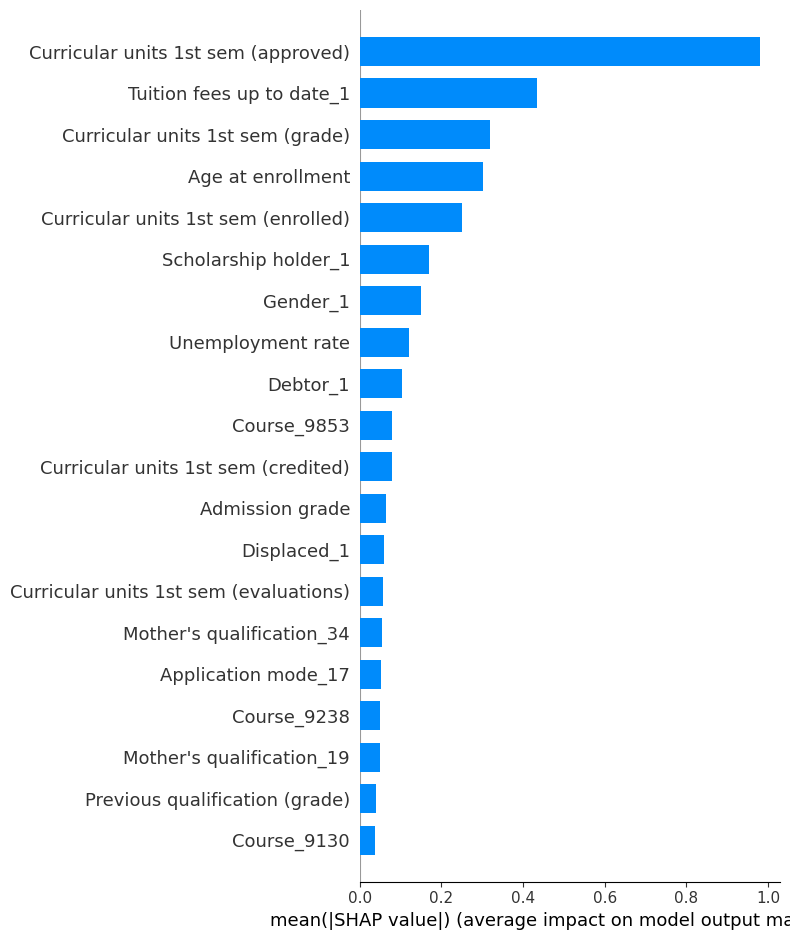

In [ ]:
# SHAP Bar Plot (Global Feature Importance)
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=True
)

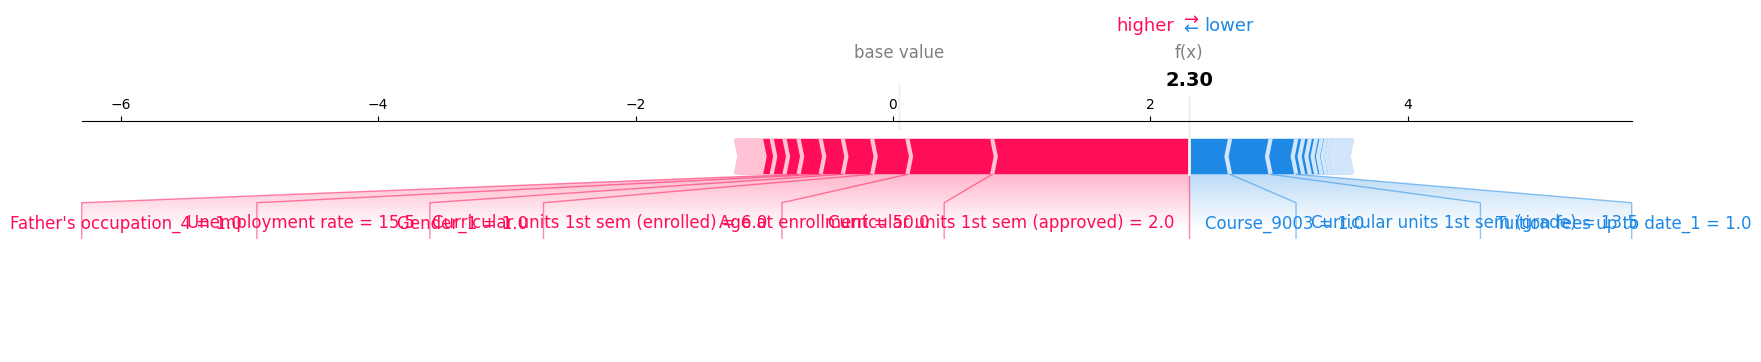

In [ ]:
# LOCAL EXPLANATION — Individual Student Prediction
# Pick a dropout case
dropout_index = np.where(y_test == 1)[0][0]

shap.force_plot(
    explainer.expected_value,
    shap_values[dropout_index],
    X_test.iloc[dropout_index],
    matplotlib=True
)
# The force plot provides a local explanation for an individual student, showing how specific academic and financial factors collectively increase the predicted dropout risk.

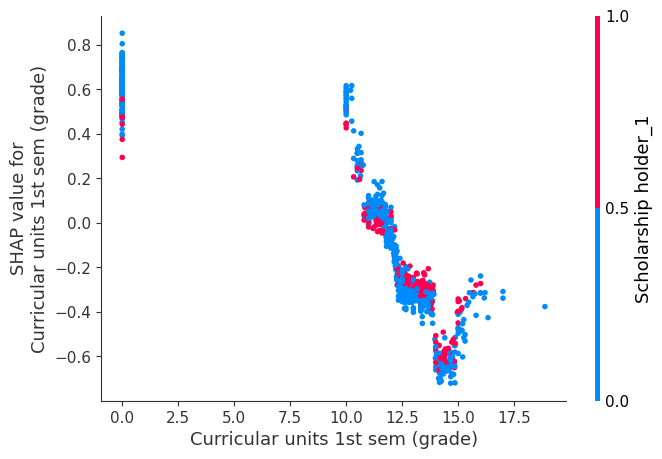

In [ ]:
# SHAP Dependence Plot
shap.dependence_plot(
    "Curricular units 1st sem (grade)",
    shap_values,
    X_test
)
# Shows non-linear effect of grades on dropout risk.

In [ ]:
# GLOBAL FEATURE IMPORTANCE → TABLE (replaces SHAP summary plot)
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
6,Curricular units 1st sem (approved),0.107078
222,Tuition fees up to date_1,0.082755
7,Curricular units 1st sem (grade),0.051776
221,Debtor_1,0.040804
224,Scholarship holder_1,0.029431
41,Course_171,0.025630
4,Curricular units 1st sem (enrolled),0.023951
2,Age at enrollment,0.023867
106,Mother's qualification_34,0.021237
137,Father's qualification_34,0.020540


In [ ]:
# TOP FEATURES TABLE (THESIS-READY)
top_features = feature_importance.head(10).reset_index(drop=True)
top_features.index += 1
top_features

,Feature,Importance
1,Curricular units 1st sem (approved),0.107078
2,Tuition fees up to date_1,0.082755
3,Curricular units 1st sem (grade),0.051776
4,Debtor_1,0.040804
5,Scholarship holder_1,0.029431
6,Course_171,0.025630
7,Curricular units 1st sem (enrolled),0.023951
8,Age at enrollment,0.023867
9,Mother's qualification_34,0.021237
10,Father's qualification_34,0.020540


In [ ]:
# SAVE TABLE
top_features.to_csv(
    f"{PROJECT_ROOT}/results/metrics/xgb_feature_importance.csv",
    index=False
)

In [ ]:
# AUTOMATIC TEXT PARAGRAPH (GLOBAL EXPLANATION)
top_feats = ", ".join(top_features["Feature"].iloc[:5])

print(
    f"The feature importance analysis indicates that {top_feats} "
    f"are the most influential predictors of student dropout. "
    f"These variables primarily reflect early academic performance "
    f"and financial stability, suggesting that students struggling "
    f"academically or financially during the initial phase of study "
    f"are at a higher risk of discontinuation."
)

The feature importance analysis indicates that Curricular units 1st sem (approved), Tuition fees up to date_1, Curricular units 1st sem (grade), Debtor_1, Scholarship holder_1 are the most influential predictors of student dropout. These variables primarily reflect early academic performance and financial stability, suggesting that students struggling academically or financially during the initial phase of study are at a higher risk of discontinuation.


In [ ]:
# CLASS-WISE MEAN COMPARISON (TEXT-FRIENDLY INSIGHT)
dropout_mean = X_test[y_test == 1].mean()
non_dropout_mean = X_test[y_test == 0].mean()

comparison = pd.DataFrame({
    "Dropout_Mean": dropout_mean,
    "Non_Dropout_Mean": non_dropout_mean,
    "Difference": dropout_mean - non_dropout_mean
})

comparison = comparison.loc[top_features["Feature"]]
comparison

,Dropout_Mean,Non_Dropout_Mean,Difference
Curricular units 1st sem (approved),2.623239,5.863561,-3.240321
Tuition fees up to date_1,0.654930,0.973378,-0.318448
Curricular units 1st sem (grade),7.147788,12.436289,-5.288501
Debtor_1,0.183099,0.063228,0.119871
Scholarship holder_1,0.102113,0.336106,-0.233994
Course_171,0.084507,0.038270,0.046237
Curricular units 1st sem (enrolled),5.904930,6.633943,-0.729014
Age at enrollment,27.014085,21.918469,5.095615
Mother's qualification_34,0.073944,0.019967,0.053977
Father's qualification_34,0.056338,0.018303,0.038035


In [ ]:
# Create a mapping for simple names
feature_name_map = {
    "Curricular units 1st sem (approved)": "Subjects passed (1st semester)",
    "Curricular units 1st sem (grade)": "1st semester grades",
    "Tuition fees up to date_1": "Tuition fees paid",
    "Debtor_1": "Has outstanding debt",
    "Scholarship holder_1": "Has scholarship",
    "Curricular units 1st sem (enrolled)": "Subjects enrolled",
    "Age at enrollment": "Student age",
    "Previous qualification (grade)": "Previous exam grade",
    "Admission grade": "Admission score"
}

# Rename columns in dataset (for SHAP display only)
X_test_renamed = X_test.rename(columns=feature_name_map)

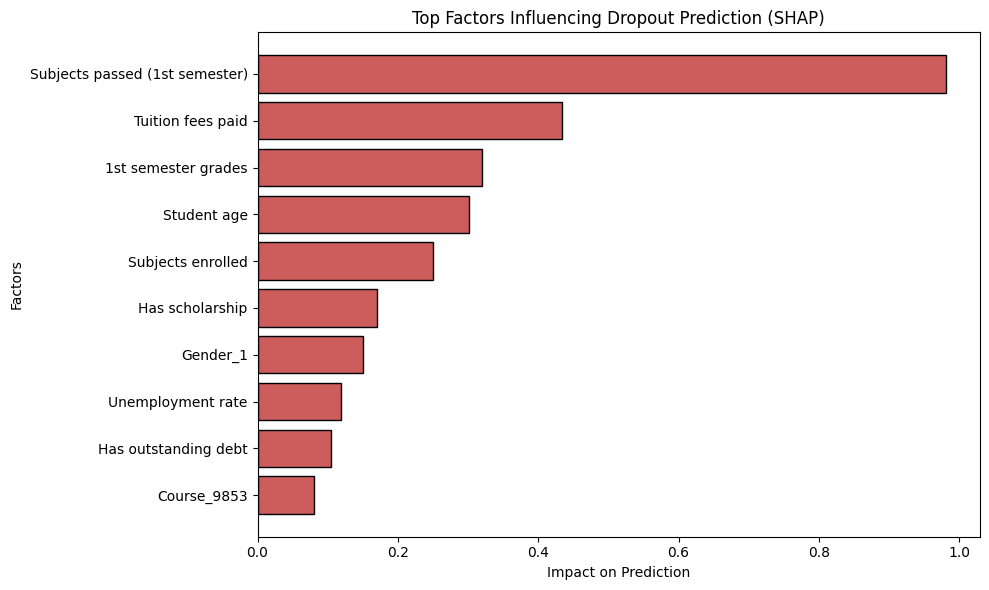

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Calculate mean SHAP values
shap_importance = pd.DataFrame({
    "Feature": X_test_renamed.columns,
    "Impact": np.abs(shap_values).mean(axis=0)
})

# Get top 10
shap_importance = shap_importance.sort_values(
    by="Impact",
    ascending=False
).head(10)

# Plot
plt.figure(figsize=(10,6))

plt.barh(
    shap_importance["Feature"],
    shap_importance["Impact"],
    color="indianred",
    edgecolor="black"
)

plt.gca().invert_yaxis()

plt.title("Top Factors Influencing Dropout Prediction (SHAP)")
plt.xlabel("Impact on Prediction")
plt.ylabel("Factors")

plt.tight_layout()
plt.show()

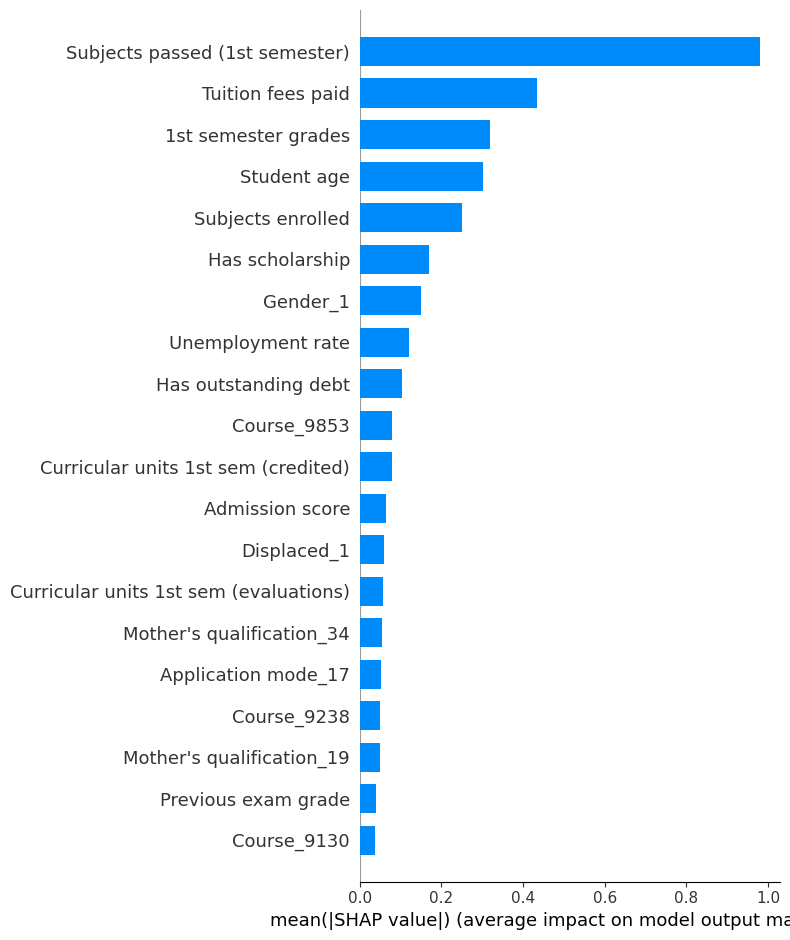

In [ ]:
import shap

shap.summary_plot(
    shap_values,
    X_test_renamed,
    plot_type="bar"
)

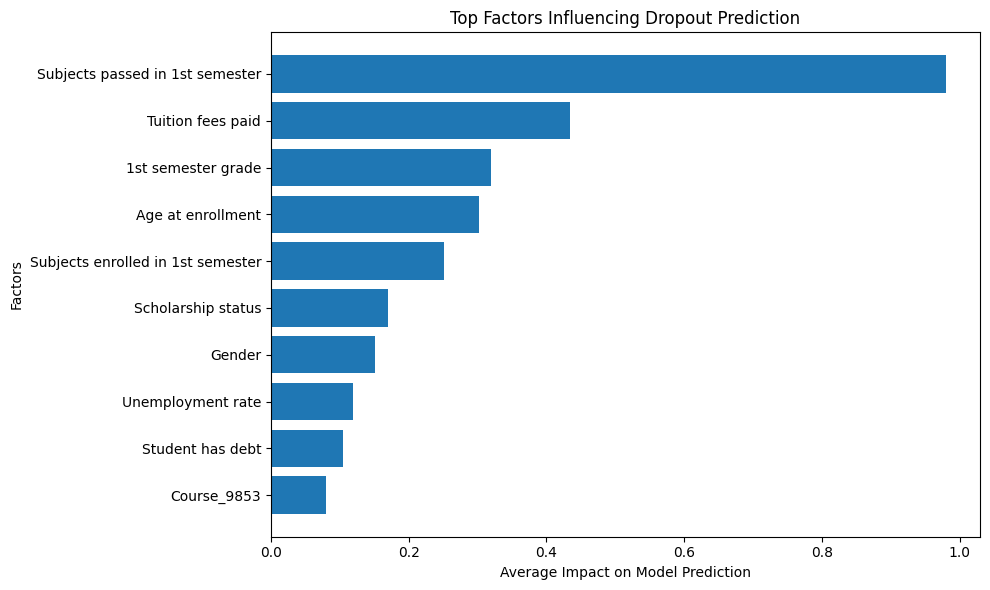

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Calculate mean absolute SHAP value for each feature
shap_importance = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean_SHAP_Value": np.abs(shap_values).mean(axis=0)
})

# Sort top 10
shap_importance = shap_importance.sort_values(
    by="Mean_SHAP_Value",
    ascending=False
).head(10)

# Rename technical feature names into simple names
feature_name_map = {
    "Curricular units 1st sem (approved)": "Subjects passed in 1st semester",
    "Tuition fees up to date_1": "Tuition fees paid",
    "Curricular units 1st sem (grade)": "1st semester grade",
    "Debtor_1": "Student has debt",
    "Scholarship holder_1": "Scholarship status",
    "Curricular units 1st sem (enrolled)": "Subjects enrolled in 1st semester",
    "Age at enrollment": "Age at enrollment",
    "Gender_1": "Gender",
    "Previous qualification (grade)": "Previous qualification grade",
    "Admission grade": "Admission grade"
}

shap_importance["Simple_Feature"] = shap_importance["Feature"].replace(feature_name_map)

# Plot easy-to-understand SHAP importance chart
plt.figure(figsize=(10, 6))

plt.barh(
    shap_importance["Simple_Feature"],
    shap_importance["Mean_SHAP_Value"]
)

plt.gca().invert_yaxis()
plt.title("Top Factors Influencing Dropout Prediction")
plt.xlabel("Average Impact on Model Prediction")
plt.ylabel("Factors")
plt.tight_layout()
plt.show()

In [ ]:
# TEXT PARAGRAPH (INDIVIDUAL-LEVEL EXPLANATION)
print(
    "Students predicted as dropouts generally exhibit lower first-semester "
    "academic performance and weaker financial indicators when compared to "
    "non-dropout students. The model assigns higher dropout risk when multiple "
    "academic and financial risk factors occur simultaneously."
)

Students predicted as dropouts generally exhibit lower first-semester academic performance and weaker financial indicators when compared to non-dropout students. The model assigns higher dropout risk when multiple academic and financial risk factors occur simultaneously.


In [ ]:
# FINAL SUMMARY TEXT (FOR CONCLUSION / DISCUSSION)
print(
    "Overall, the explainability analysis confirms that early academic outcomes "
    "and financial conditions are the dominant drivers of student dropout. "
    "Demographic variables play a secondary role, reinforcing the importance "
    "of early academic monitoring and financial support interventions."
)

Overall, the explainability analysis confirms that early academic outcomes and financial conditions are the dominant drivers of student dropout. Demographic variables play a secondary role, reinforcing the importance of early academic monitoring and financial support interventions.
